In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.datasets import load_digits
import time
import warnings
warnings.filterwarnings('ignore')


# Generate sample customer data (since we don't have actual dataset)
np.random.seed(42)
n_customers = 300

data = {
    'Annual_Income': np.random.normal(50000, 15000, n_customers),
    'Spending_Score': np.random.normal(50, 25, n_customers),
    'Age': np.random.normal(40, 12, n_customers),
    'Purchase_Frequency': np.random.normal(10, 5, n_customers)
}
df = pd.DataFrame(data)


PART A: K-MEANS CLUSTERING


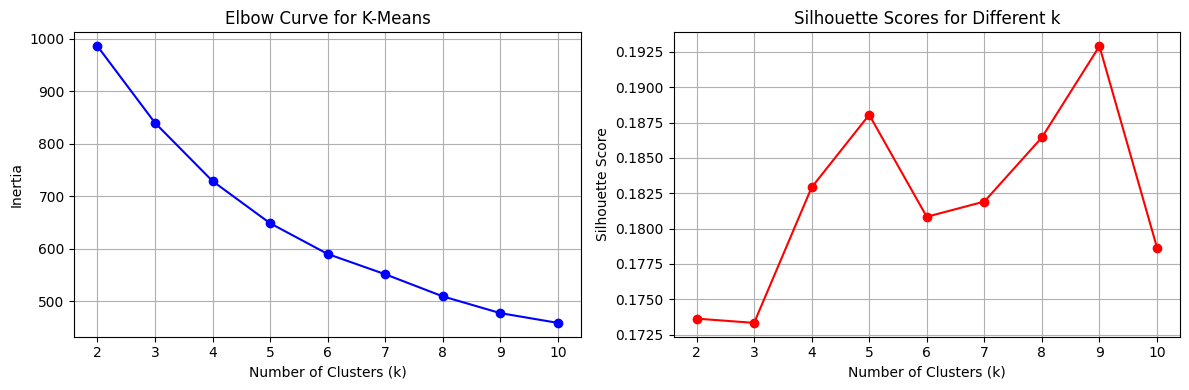

Optimal k based on silhouette score: 9


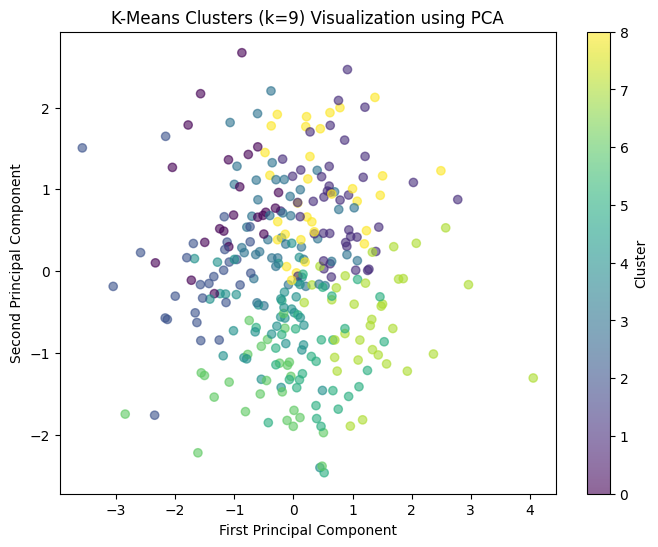

In [27]:
# PART A: K-MEANS CLUSTERING
print("=" * 50)
print("PART A: K-MEANS CLUSTERING")
print("=" * 50)

# Preprocess and scale data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

# Apply K-Means with different k values (2-10)
k_values = range(2, 11)
inertias = []
silhouette_scores = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))

# Plot elbow curve
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(k_values, inertias, 'bo-')

plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Curve for K-Means')
plt.grid(True)
# Plot silhouette scores
plt.subplot(1, 2, 2)
plt.plot(k_values, silhouette_scores, 'ro-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Scores for Different k')
plt.grid(True)
plt.tight_layout()
plt.show()
optimal_k = k_values[np.argmax(silhouette_scores)]
print(f"Optimal k based on silhouette score: {optimal_k}")
# Visualize clusters using PCA
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
clusters = kmeans_final.fit_predict(X_scaled)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='viridis', alpha=0.6)
plt.xlabel('First Principal Component')

plt.ylabel('Second Principal Component')
plt.title(f'K-Means Clusters (k={optimal_k}) Visualization using PCA')
plt.colorbar(label='Cluster')
plt.show()




PART B: HIERARCHICAL CLUSTERING


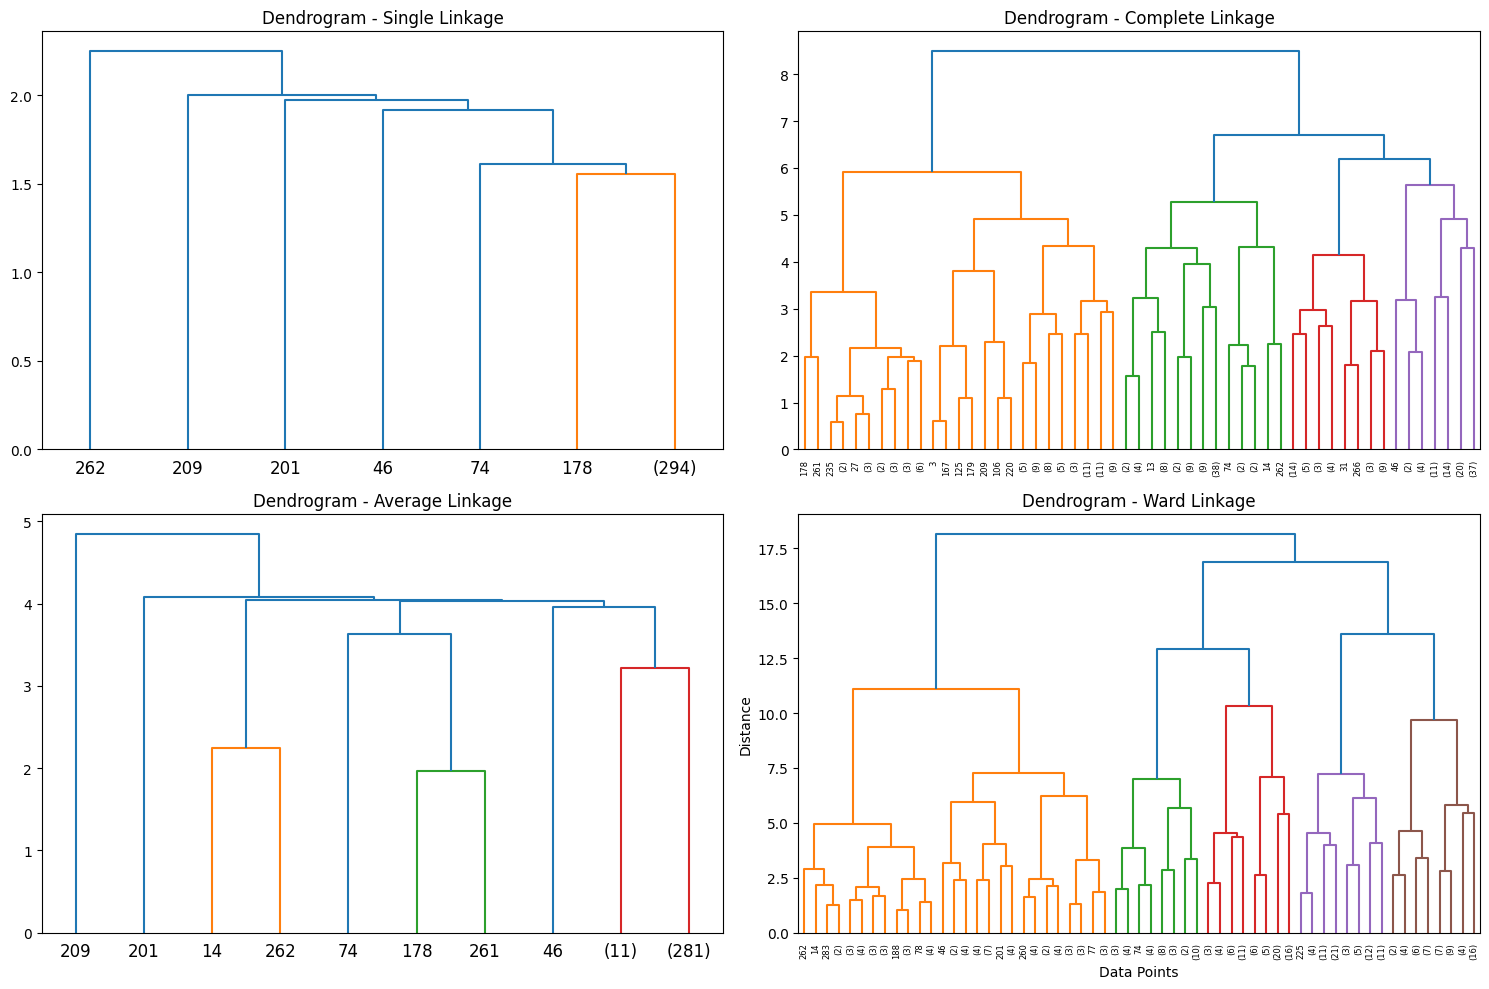

Single Linkage - Silhouette Score: 0.055
Complete Linkage - Silhouette Score: 0.120
Average Linkage - Silhouette Score: 0.005
Ward Linkage - Silhouette Score: 0.159


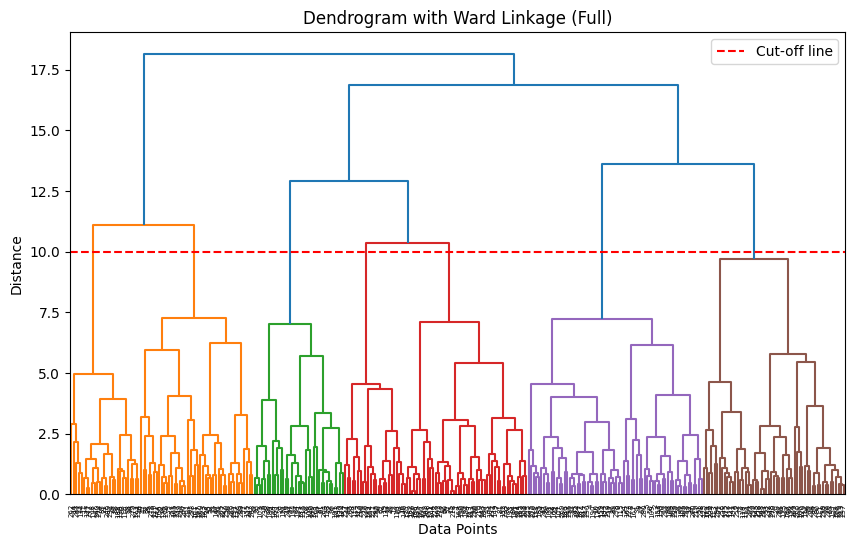

In [28]:
# PART B: HIERARCHICAL CLUSTERING
print("\n" + "=" * 50)
print("PART B: HIERARCHICAL CLUSTERING")
print("=" * 50)

# Different linkage methods
linkage_methods = ['single', 'complete', 'average', 'ward']

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.ravel()

for idx, method in enumerate(linkage_methods):
    # Compute linkage matrix
    linkage_matrix = linkage(X_scaled, method=method)

    # Plot dendrogram
    dendrogram(linkage_matrix, ax=axes[idx], truncate_mode='level', p=5)
    axes[idx].set_title(f'Dendrogram - {method.capitalize()} Linkage')


axes[idx].set_xlabel('Data Points')
axes[idx].set_ylabel('Distance')
plt.tight_layout()
plt.show()
# Apply Agglomerative Clustering with different methods
for method in linkage_methods:
    if method == 'ward':
        agg_clustering = AgglomerativeClustering(n_clusters=optimal_k, linkage=method)
    else:
        agg_clustering = AgglomerativeClustering(n_clusters=optimal_k, linkage=method)
    agg_labels = agg_clustering.fit_predict(X_scaled)
    sil_score = silhouette_score(X_scaled, agg_labels)
    print(f"{method.capitalize()} Linkage - Silhouette Score: {sil_score:.3f}")

# Determine optimal number of clusters from dendrogram (Ward method)
linkage_matrix = linkage(X_scaled, method='ward')
plt.figure(figsize=(10, 6))
dendrogram(linkage_matrix)
plt.title('Dendrogram with Ward Linkage (Full)')
plt.xlabel('Data Points')
plt.ylabel('Distance')
plt.axhline(y=10, color='r', linestyle='--', label='Cut-off line')
plt.legend()
plt.show()




PART C: COMPARISON

Computation Time Comparison:
K-Means (k=9): 0.1087 seconds
Hierarchical (Ward, k=9): 0.0041 seconds

Cluster Characteristics Comparison:
----------------------------------------

K-Means Cluster Centers (Original Scale):
Cluster 0:
  Annual_Income: 47487.49
  Spending_Score: 46.14
  Age: 52.88
  Purchase_Frequency: 3.04
Cluster 1:
  Annual_Income: 53297.21
  Spending_Score: 19.92
  Age: 44.46
  Purchase_Frequency: 11.02
Cluster 2:
  Annual_Income: 39246.75
  Spending_Score: 78.65
  Age: 47.34
  Purchase_Frequency: 6.32
Cluster 3:
  Annual_Income: 33041.54
  Spending_Score: 42.55
  Age: 42.61
  Purchase_Frequency: 13.96
Cluster 4:
  Annual_Income: 46698.99
  Spending_Score: 38.14
  Age: 28.80
  Purchase_Frequency: 5.55
Cluster 5:
  Annual_Income: 69115.87
  Spending_Score: 65.10
  Age: 35.42
  Purchase_Frequency: 9.24
Cluster 6:
  Annual_Income: 42512.62
  Spending_Score: 82.88
  Age: 29.21
  Purchase_Frequency: 12.87
Cluster 7:
  Annual_Income: 62180.40
  Spending_

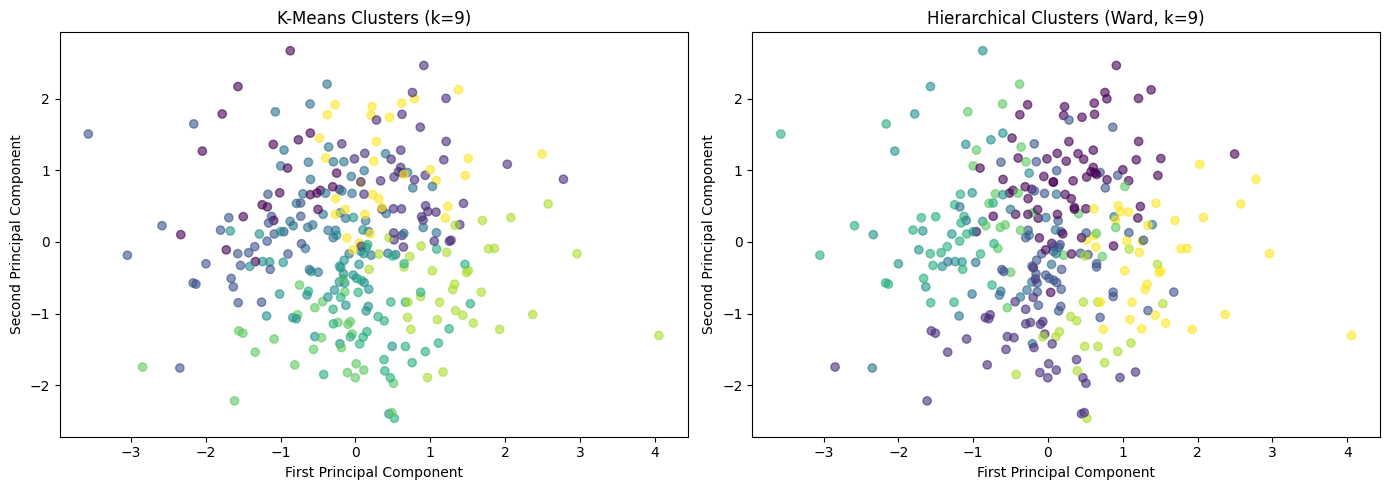


BUSINESS INTERPRETATION


In [29]:
# PART C: COMPARISON
print("\n" + "=" * 50)
print("PART C: COMPARISON")
print("=" * 50)

# Compare computation time
print("\nComputation Time Comparison:")
# K-Means time
start_time = time.time()
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)
kmeans_time = time.time() - start_time
print(f"K-Means (k={optimal_k}): {kmeans_time:.4f} seconds")

# Hierarchical time (Ward)
start_time = time.time()
hierarchical = AgglomerativeClustering(n_clusters=optimal_k, linkage='ward')
hierarchical_labels = hierarchical.fit_predict(X_scaled)
hierarchical_time = time.time() - start_time
print(f"Hierarchical (Ward, k={optimal_k}): {hierarchical_time:.4f} seconds")
print("\nCluster Characteristics Comparison:")
print("-" * 40)

# Add cluster labels to original dataframe
df['KMeans_Cluster'] = kmeans_labels
df['Hierarchical_Cluster'] = hierarchical_labels
print("\nK-Means Cluster Centers (Original Scale):")
kmeans_centers = scaler.inverse_transform(kmeans.cluster_centers_)
for i in range(optimal_k):
    print(f"Cluster {i}:")
    for j, col in enumerate(df.columns[:4]):
        print(f"  {col}: {kmeans_centers[i, j]:.2f}")

print("\nHierarchical Cluster Statistics:")
for i in range(optimal_k):
    cluster_data = df[df['Hierarchical_Cluster'] == i]
    print(f"\nCluster {i} (size: {len(cluster_data)}):")
    for col in df.columns[:4]:
        print(f"  {col} - Mean: {cluster_data[col].mean():.2f}, Std: {cluster_data[col].std():.2f}")

# Visual comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# K-Means clusters
axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels, cmap='viridis', alpha=0.6)
axes[0].set_xlabel('First Principal Component')
axes[0].set_ylabel('Second Principal Component')
axes[0].set_title(f'K-Means Clusters (k={optimal_k})')

# Hierarchical clusters
axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=hierarchical_labels, cmap='viridis', alpha=0.6)
axes[1].set_xlabel('First Principal Component')
axes[1].set_ylabel('Second Principal Component')
axes[1].set_title(f'Hierarchical Clusters (Ward, k={optimal_k})')

plt.tight_layout()
plt.show()

# Business interpretation
print("\n" + "=" * 50)
print("BUSINESS INTERPRETATION")
print("=" * 50)




# POST LAB


PART D: DBSCAN CLUSTERING AND COMPARISON WITH K-MEANS
Best DBSCAN parameters: eps=0.7, min_samples=5
Number of clusters: 7, Noise points: 170
Silhouette Score: -0.169


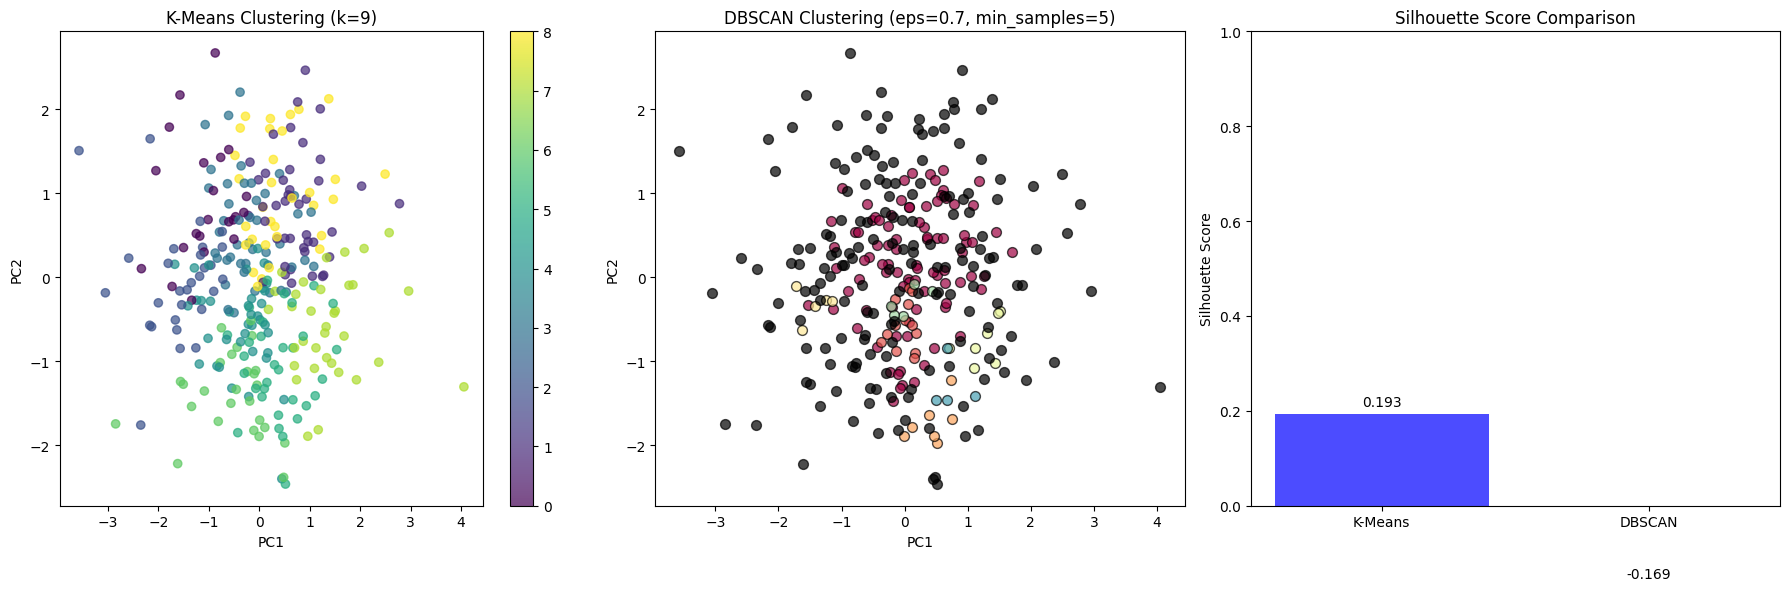


Comparison Summary:
K-Means: 9 clusters, Silhouette: 0.193
DBSCAN: 7 clusters, 170 noise points, Silhouette: -0.169


In [30]:
# PART D: DBSCAN CLUSTERING AND COMPARISON WITH K-MEANS
print("\n" + "=" * 50)
print("PART D: DBSCAN CLUSTERING AND COMPARISON WITH K-MEANS")
print("=" * 50)

# Apply DBSCAN
eps_values = [0.3, 0.5, 0.7, 1.0]
min_samples_values = [5, 10, 15]

dbscan_results = []

for eps in eps_values:
    for min_samples in min_samples_values:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        dbscan_labels = dbscan.fit_predict(X_scaled)

        # Calculate number of clusters (excluding noise labeled as -1)
        n_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
        n_noise = list(dbscan_labels).count(-1)

        if n_clusters > 1:  # Only calculate metrics if we have clusters
            sil_score = silhouette_score(X_scaled, dbscan_labels) if n_clusters > 1 else -1
        else:
            sil_score = -1

        dbscan_results.append({
            'eps': eps,
            'min_samples': min_samples,
            'n_clusters': n_clusters,
            'n_noise': n_noise,
            'silhouette': sil_score
        })

# Find best DBSCAN parameters
best_dbscan = max(dbscan_results, key=lambda x: x['silhouette'] if x['silhouette'] > -1 else -2)
print(f"Best DBSCAN parameters: eps={best_dbscan['eps']}, min_samples={best_dbscan['min_samples']}")
print(f"Number of clusters: {best_dbscan['n_clusters']}, Noise points: {best_dbscan['n_noise']}")
print(f"Silhouette Score: {best_dbscan['silhouette']:.3f}")

# Apply best DBSCAN
dbscan_best = DBSCAN(eps=best_dbscan['eps'], min_samples=best_dbscan['min_samples'])
dbscan_labels = dbscan_best.fit_predict(X_scaled)

# Compare with K-Means
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
kmeans_labels = kmeans_final.fit_predict(X_scaled)

# Visualization comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# PCA for 2D visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# K-Means plot
scatter1 = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels, cmap='viridis', alpha=0.7)
axes[0].set_title(f'K-Means Clustering (k={optimal_k})')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
plt.colorbar(scatter1, ax=axes[0])

# DBSCAN plot
unique_labels = set(dbscan_labels)
colors = plt.cm.Spectral(np.linspace(0, 1, len(unique_labels)))
for k, col in zip(unique_labels, colors):
    if k == -1:
        # Black used for noise.
        col = 'black'

    class_member_mask = (dbscan_labels == k)

    xy = X_pca[class_member_mask]
    axes[1].scatter(xy[:, 0], xy[:, 1], c=[col], alpha=0.7, s=50, edgecolors='k')

axes[1].set_title(f'DBSCAN Clustering (eps={best_dbscan["eps"]}, min_samples={best_dbscan["min_samples"]})')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')

# Comparison metrics
methods = ['K-Means', 'DBSCAN']
sil_scores = [
    silhouette_score(X_scaled, kmeans_labels),
    silhouette_score(X_scaled, dbscan_labels) if best_dbscan['silhouette'] > -1 else 0
]

axes[2].bar(methods, sil_scores, color=['blue', 'green'], alpha=0.7)
axes[2].set_title('Silhouette Score Comparison')
axes[2].set_ylabel('Silhouette Score')
axes[2].set_ylim(0, 1)

for i, v in enumerate(sil_scores):
    axes[2].text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

print("\nComparison Summary:")
print(f"K-Means: {optimal_k} clusters, Silhouette: {sil_scores[0]:.3f}")
print(f"DBSCAN: {best_dbscan['n_clusters']} clusters, {best_dbscan['n_noise']} noise points, Silhouette: {sil_scores[1]:.3f}")

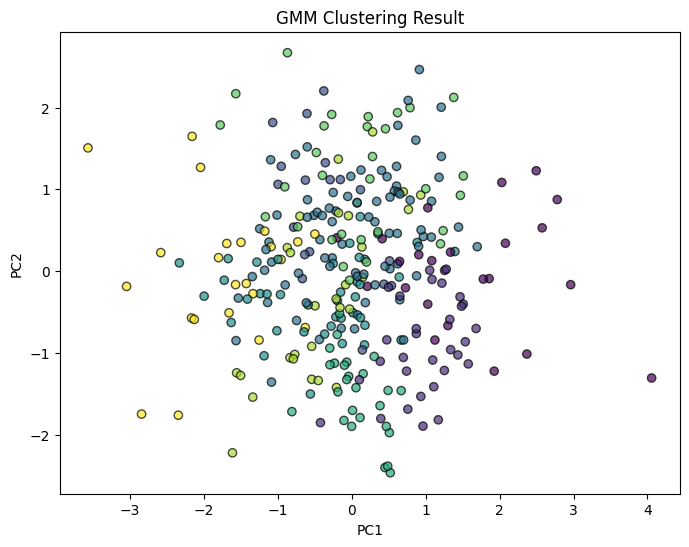

In [31]:
# GMM probability contours (simplified)
from sklearn.mixture import GaussianMixture

# Fit GMM
gmm = GaussianMixture(n_components=optimal_k, random_state=42)
gmm_labels = gmm.fit_predict(X_scaled)

# Create a grid in the original PCA space
x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 50), np.linspace(y_min, y_max, 50))

# For simplicity, just show the cluster assignments
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(X_pca[:, 0], X_pca[:, 1], c=gmm_labels, cmap='viridis', alpha=0.7, edgecolors='k')
ax.set_title('GMM Clustering Result')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
plt.show()


PART F: CLUSTER VALIDATION USING MULTIPLE METRICS
Cluster Validation Metrics:
Algorithm       Silhouette   CH Index     DB Index     Clusters  
----------------------------------------------------------------------
K-Means         0.193        55           1.330        9         
DBSCAN          0.000        0            inf          7         
GMM             0.098        34           1.828        9         
Hierarchical    0.159        46           1.474        9         


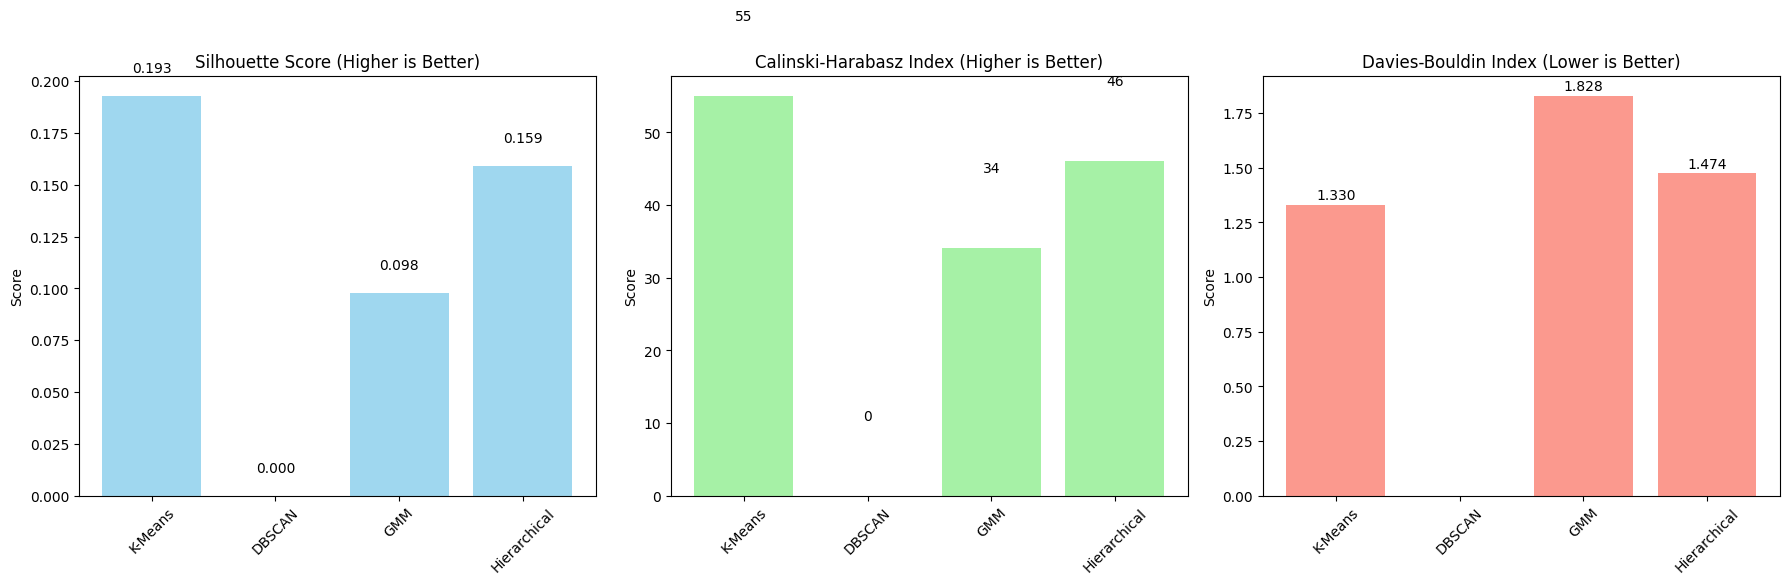


Validation Insights:
• Silhouette Score: Measures how similar objects are to their cluster vs other clusters
• Calinski-Harabasz: Ratio of between-cluster dispersion to within-cluster dispersion
• Davies-Bouldin: Average similarity measure of each cluster with its most similar cluster
• Higher Silhouette and CH scores indicate better clustering
• Lower DB score indicates better clustering


In [32]:
# PART F: CLUSTER VALIDATION USING MULTIPLE METRICS
print("\n" + "=" * 50)
print("PART F: CLUSTER VALIDATION USING MULTIPLE METRICS")
print("=" * 50)

# Get cluster labels from different algorithms
algorithms = {
    'K-Means': kmeans_labels,
    'DBSCAN': dbscan_labels,
    'GMM': gmm_labels,
    'Hierarchical': agg_labels
}

validation_results = []

for name, labels in algorithms.items():
    if len(set(labels)) > 1 and -1 not in labels:  # Valid clustering
        sil = silhouette_score(X_scaled, labels)
        ch = calinski_harabasz_score(X_scaled, labels)
        db = davies_bouldin_score(X_scaled, labels)
    else:
        sil, ch, db = 0, 0, float('inf')

    validation_results.append({
        'Algorithm': name,
        'Silhouette': sil,
        'Calinski-Harabasz': ch,
        'Davies-Bouldin': db,
        'Num_Clusters': len(set(labels)) - (1 if -1 in labels else 0)
    })

# Display results
print("Cluster Validation Metrics:")
print(f"{'Algorithm':<15} {'Silhouette':<12} {'CH Index':<12} {'DB Index':<12} {'Clusters':<10}")
print("-" * 70)
for result in validation_results:
    print(f"{result['Algorithm']:<15} {result['Silhouette']:<12.3f} {result['Calinski-Harabasz']:<12.0f} {result['Davies-Bouldin']:<12.3f} {result['Num_Clusters']:<10}")

# Visualize validation metrics
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

algorithms_list = [r['Algorithm'] for r in validation_results]
sil_scores = [r['Silhouette'] for r in validation_results]
ch_scores = [r['Calinski-Harabasz'] for r in validation_results]
db_scores = [r['Davies-Bouldin'] for r in validation_results]

axes[0].bar(algorithms_list, sil_scores, color='skyblue', alpha=0.8)
axes[0].set_title('Silhouette Score (Higher is Better)')
axes[0].set_ylabel('Score')
axes[0].tick_params(axis='x', rotation=45)
for i, v in enumerate(sil_scores):
    axes[0].text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom')

axes[1].bar(algorithms_list, ch_scores, color='lightgreen', alpha=0.8)
axes[1].set_title('Calinski-Harabasz Index (Higher is Better)')
axes[1].set_ylabel('Score')
axes[1].tick_params(axis='x', rotation=45)
for i, v in enumerate(ch_scores):
    axes[1].text(i, v + 10, f'{v:.0f}', ha='center', va='bottom')

axes[2].bar(algorithms_list, db_scores, color='salmon', alpha=0.8)
axes[2].set_title('Davies-Bouldin Index (Lower is Better)')
axes[2].set_ylabel('Score')
axes[2].tick_params(axis='x', rotation=45)
for i, v in enumerate(db_scores):
    axes[2].text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

print("\nValidation Insights:")
print("• Silhouette Score: Measures how similar objects are to their cluster vs other clusters")
print("• Calinski-Harabasz: Ratio of between-cluster dispersion to within-cluster dispersion")
print("• Davies-Bouldin: Average similarity measure of each cluster with its most similar cluster")
print("• Higher Silhouette and CH scores indicate better clustering")
print("• Lower DB score indicates better clustering")


PART G: IMAGE SEGMENTATION USING CLUSTERING


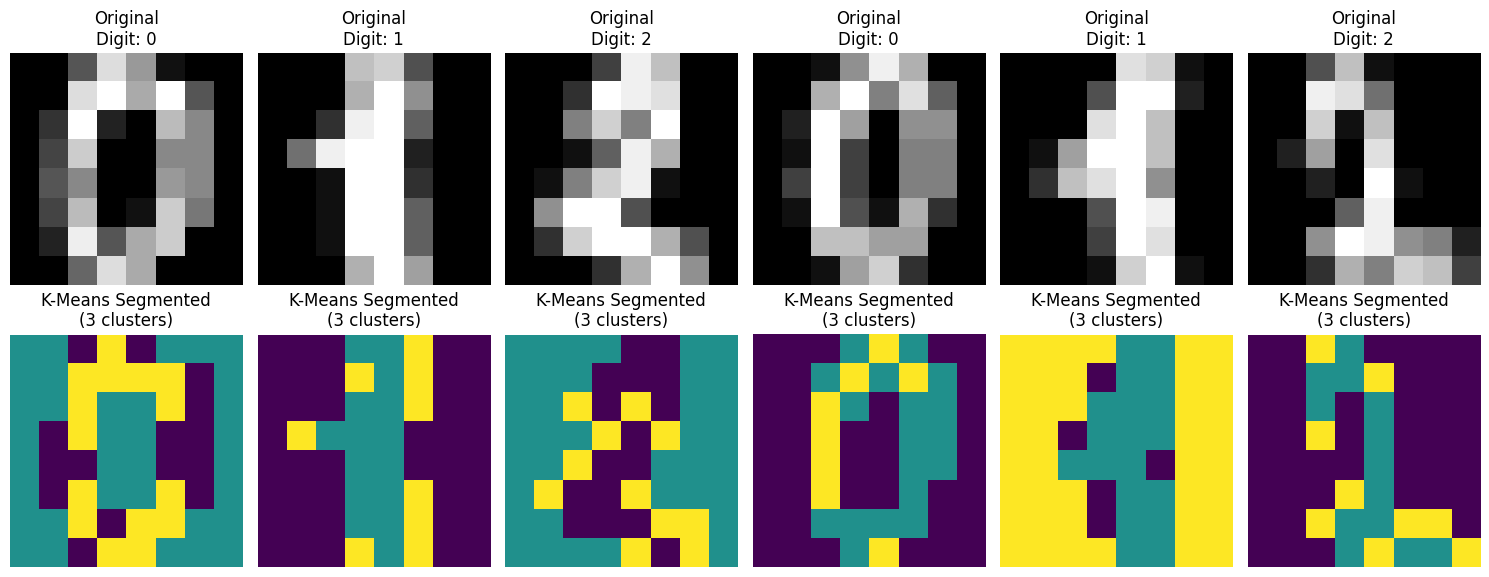


Segmentation Analysis:
Image 1 (Digit 0) - 2 clusters: Silhouette = 0.750
Image 1 (Digit 0) - 3 clusters: Silhouette = 0.741
Image 1 (Digit 0) - 4 clusters: Silhouette = 0.758
Image 1 (Digit 0) - 5 clusters: Silhouette = 0.760
Image 2 (Digit 1) - 2 clusters: Silhouette = 0.836
Image 2 (Digit 1) - 3 clusters: Silhouette = 0.836
Image 2 (Digit 1) - 4 clusters: Silhouette = 0.858
Image 2 (Digit 1) - 5 clusters: Silhouette = 0.864
Image 3 (Digit 2) - 2 clusters: Silhouette = 0.801
Image 3 (Digit 2) - 3 clusters: Silhouette = 0.771
Image 3 (Digit 2) - 4 clusters: Silhouette = 0.799
Image 3 (Digit 2) - 5 clusters: Silhouette = 0.819
Image 4 (Digit 0) - 2 clusters: Silhouette = 0.766
Image 4 (Digit 0) - 3 clusters: Silhouette = 0.759
Image 4 (Digit 0) - 4 clusters: Silhouette = 0.766
Image 4 (Digit 0) - 5 clusters: Silhouette = 0.764
Image 5 (Digit 1) - 2 clusters: Silhouette = 0.884
Image 5 (Digit 1) - 3 clusters: Silhouette = 0.827
Image 5 (Digit 1) - 4 clusters: Silhouette = 0.811
Image 5

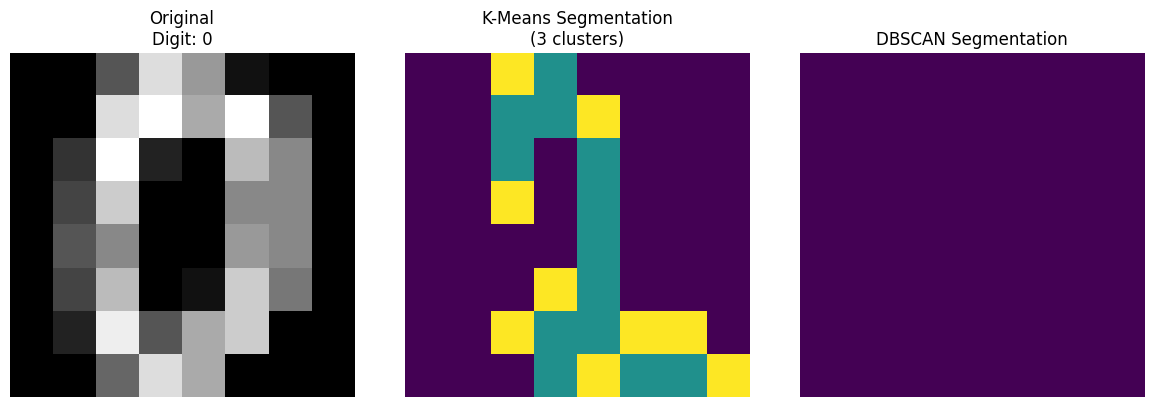

In [33]:
# PART G: IMAGE SEGMENTATION USING CLUSTERING
print("\n" + "=" * 50)
print("PART G: IMAGE SEGMENTATION USING CLUSTERING")
print("=" * 50)

# Load digits dataset for image segmentation
digits = load_digits()
images = digits.images
labels = digits.target

# Select a few sample images
sample_indices = [0, 1, 2, 10, 11, 12]  # Different digits
sample_images = images[sample_indices]
sample_labels = labels[sample_indices]

fig, axes = plt.subplots(2, len(sample_indices), figsize=(15, 6))

for i, (img, label) in enumerate(zip(sample_images, sample_labels)):
    # Original image
    axes[0, i].imshow(img, cmap='gray')
    axes[0, i].set_title(f'Original\nDigit: {label}')
    axes[0, i].axis('off')

    # Segment using K-Means clustering
    img_flat = img.reshape(-1, 1)  # Flatten to 1D for clustering
    scaler_img = StandardScaler()
    img_scaled = scaler_img.fit_transform(img_flat)

    # K-Means with 3 clusters (background, foreground light, foreground dark)
    kmeans_img = KMeans(n_clusters=3, random_state=42, n_init=10)
    clusters = kmeans_img.fit_predict(img_scaled)

    # Reshape back to image
    segmented = clusters.reshape(img.shape)

    # Visualize segmented image
    axes[1, i].imshow(segmented, cmap='viridis')
    axes[1, i].set_title(f'K-Means Segmented\n(3 clusters)')
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

# Quantitative analysis of segmentation
print("\nSegmentation Analysis:")
for i, (img, label) in enumerate(zip(sample_images, sample_labels)):
    img_flat = img.reshape(-1, 1)
    img_scaled = StandardScaler().fit_transform(img_flat)

    # Try different numbers of clusters
    for n_clusters in [2, 3, 4, 5]:
        kmeans_seg = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
        seg_labels = kmeans_seg.fit_predict(img_scaled)
        sil = silhouette_score(img_scaled, seg_labels)
        print(f"Image {i+1} (Digit {label}) - {n_clusters} clusters: Silhouette = {sil:.3f}")

# Compare with DBSCAN for image segmentation
print("\nDBSCAN Segmentation:")
for i, (img, label) in enumerate(zip(sample_images, sample_labels)):
    img_flat = img.reshape(-1, 1)
    img_scaled = StandardScaler().fit_transform(img_flat)

    dbscan_img = DBSCAN(eps=0.8, min_samples=5)
    dbscan_labels = dbscan_img.fit_predict(img_scaled)

    n_clusters_db = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
    n_noise_db = list(dbscan_labels).count(-1)

    print(f"Image {i+1} (Digit {label}) - DBSCAN: {n_clusters_db} clusters, {n_noise_db} noise points")

# Visualize DBSCAN segmentation for one image
sample_img = sample_images[0]
sample_label = sample_labels[0]

img_flat = sample_img.reshape(-1, 1)
img_scaled = StandardScaler().fit_transform(img_flat)

dbscan_img = DBSCAN(eps=0.8, min_samples=5)
dbscan_seg_labels = dbscan_img.fit_predict(img_scaled)
dbscan_segmented = dbscan_seg_labels.reshape(sample_img.shape)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(sample_img, cmap='gray')
axes[0].set_title(f'Original\nDigit: {sample_label}')
axes[0].axis('off')

axes[1].imshow(segmented, cmap='viridis')
axes[1].set_title('K-Means Segmentation\n(3 clusters)')
axes[1].axis('off')

axes[2].imshow(dbscan_segmented, cmap='viridis')
axes[2].set_title('DBSCAN Segmentation')
axes[2].axis('off')

plt.tight_layout()
plt.show()

In [34]:
# Compare with original high-dimensional clustering
kmeans_original = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
kmeans_original_labels = kmeans_original.fit_predict(X_scaled)
sil_original = silhouette_score(X_scaled, kmeans_original_labels)
print(f"Original clustering silhouette score: {sil_original:.4f}")

Original clustering silhouette score: 0.1929
